In [1]:

import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torchvision import models
from torch.amp.grad_scaler import GradScaler
from torch.amp.autocast_mode import autocast
import numpy as np
from tqdm import tqdm
import torch
import os
from transformers import MobileNetV2Config, MobileNetV2Model
import torch.nn as nn

from torch.utils.data import DataLoader, WeightedRandomSampler


2026-03-28 13:50:28.261923: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-28 13:50:28.272555: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774686028.284469 1032094 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774686028.288390 1032094 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774686028.299211 1032094 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
import sys
sys.path.append("/mnt/Personal/Projects/Autofocus/Code/Universal")

import pytorch_start # type: ignore
pytorch_start.activate_gpu(print_details=True)


                               ACTIVE GPU CONFIGURATION                              
+-------------+------------------------------------+---------------+--------------+---------------+
|   Device ID | Name                               |   Memory (GB) | PCI Bus ID   | GFX Version   |
+=============+====================================+===============+==============+===============+
|           0 | NVIDIA GeForce RTX 3050 Laptop GPU |          3.69 | Unknown      | Native        |
+-------------+------------------------------------+---------------+--------------+---------------+

Configured GPU 0: _CudaDeviceProperties(name='NVIDIA GeForce RTX 3050 Laptop GPU', major=8, minor=6, total_memory=3778MB, multi_processor_count=16, uuid=1fb0444c-042f-2836-2dde-93bbe9dca9b5, L2_cache_size=1MB)


In [3]:
dataset_type = "Train"
dataset_path = "/mnt/Velocity_Vault/Datasets/Autofocus/Dataset/"+dataset_type
model_path = "/mnt/Velocity_Vault/Datasets/Autofocus/Model/"

label_path = dataset_path+"/label.mm"
patch_path = dataset_path+"/patch.mm"

meta_data_path = dataset_path+"/meta.txt"

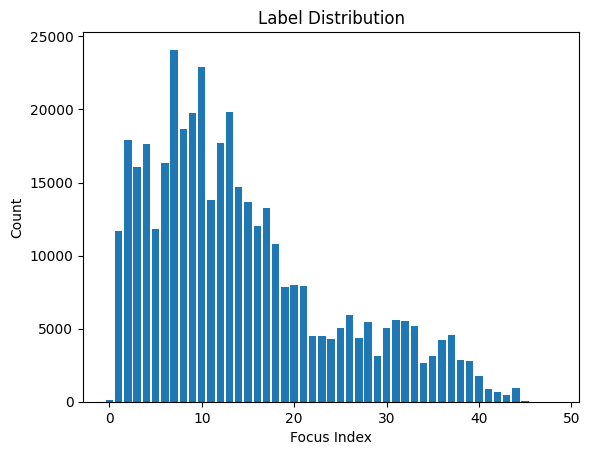

In [4]:
with open(meta_data_path, "r") as f:
    meta_data = json.load(f)
        
labels = np.memmap(label_path, dtype=np.uint8, mode='r')

hist = np.bincount(labels, minlength=49)

# print(hist)

plt.bar(range(49), hist)
plt.title("Label Distribution")
plt.xlabel("Focus Index")
plt.ylabel("Count")
plt.show()

In [5]:
def split_indices(n, val_ratio=0.1):
    indices = np.arange(n)
    np.random.shuffle(indices)

    split = int(n * (1 - val_ratio))

    train_idx = indices[:split]
    val_idx = indices[split:]

    return train_idx, val_idx

# -----------------------------
# 1. Dataset (Optimized Memmap)
# -----------------------------
class FocalStackDataset(Dataset):
    def __init__(self, patches_path, labels_path, shape, indices=None, label_offset=0):
        
        self.patches = np.memmap(patches_path, dtype=np.uint8, mode='r', shape=shape)
        self.labels = np.memmap(labels_path, dtype=np.uint8, mode='r', shape=(shape[0],))

        self.indices = indices if indices is not None else np.arange(shape[0])
        self.label_offset = label_offset

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]

        x = torch.from_numpy(self.patches[real_idx])
        y = int(self.labels[real_idx]) - self.label_offset  

        return x, torch.tensor(y, dtype=torch.long)


In [6]:


class FocusNet(nn.Module):
    def __init__(self):
        super().__init__()

        config = MobileNetV2Config(
            num_channels=49,
            image_size=32,
            depth_multiplier=0.5,
            output_stride=8,
            finegrained_output=True
        )

        self.backbone = MobileNetV2Model(config)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.head = nn.Sequential(
            nn.Linear(1280, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 40)
        )

    def forward(self, x):
        # x: (B,40,32,32)

        outputs = self.backbone(x)
        feat = outputs.last_hidden_state   # (B, C, H, W)

        feat = self.pool(feat).flatten(1)

        out = self.head(feat)

        return out

In [7]:

# -----------------------------
# 3. Ordinal Loss
# -----------------------------

def autofocus_loss(outputs, target):
    """
    outputs: (B, 49)
    target: (B,)
    """

    class_range = torch.arange(outputs.shape[1], device=outputs.device).float()

    prob = torch.softmax(outputs, dim=1)

    pred = (prob * class_range).sum(dim=1)  # expected focus

    loss = torch.nn.functional.l1_loss(pred, target.float())

    return loss, pred



In [ ]:
from tqdm import tqdm

def train_epoch(model, loader, optimizer, scaler, device, acc_k, class_weights):
    model.train()

    total_loss = 0.0
    total_mae = 0.0
    total_acck = 0.0

    class_range = torch.arange(40, device=device).float()

    pbar = tqdm(
        loader,
        desc="Training",
        leave=False,
        dynamic_ncols=True,
        smoothing=0.1
    )

    for i, (x, y) in enumerate(pbar, 1):

        x = x.to(device, non_blocking=True).float().div(127.5).sub(1.0)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type="cuda"):
            outputs = model(x)

            prob = torch.softmax(outputs, dim=1)
            pred_cont = (prob * class_range).sum(dim=1)

            # -------------------------
            # Weighted L1 loss
            # -------------------------
            
            l1 = (pred_cont - y.float()).abs()
            weights = class_weights[y]          # (B,)
            loss = (l1 * weights).mean()
            
            # -------------------------
            # Plain L1 loss
            # -------------------------
            
            # loss = (pred_cont - y.float()).abs().mean()

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        # ---- metrics (UNWEIGHTED, important) ----
        total_loss += loss.item()

        pred = pred_cont.round().long()

        mae = (pred_cont - y).abs().mean()   # keep raw MAE for reporting
        total_mae += mae.item()

        acck_val = ((pred - y).abs() <= acc_k).float().mean()
        total_acck += acck_val.item()

        # ---- running averages ----
        avg_loss = total_loss / i
        avg_mae = total_mae / i
        avg_acck = total_acck / i

        pbar.set_postfix_str(
            f"loss={avg_loss:.3f} | mae={avg_mae:.3f} | acc@{acc_k}={avg_acck:.3f}"
        )

    return avg_loss, avg_mae, avg_acck
    

In [9]:



# -----------------------------
# 5. Main Training Script
# -----------------------------
import numpy as np
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch.optim as optim
from torch.amp.grad_scaler import GradScaler


# -----------------------------
# 1. Device
# -----------------------------
def get_device():
    return torch.device("cuda")

# -----------------------------
# 4. Sampler + DataLoader
# -----------------------------
# def create_dataloader(dataset, labels_np, weights, batch_size):
def create_dataloader(dataset, batch_size):
    
    # sample_weights = weights[labels_np]

    # sampler = WeightedRandomSampler(
    #     weights=sample_weights.tolist(),
    #     num_samples=len(sample_weights),
    #     replacement=True
    # )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        pin_memory_device="cuda",
        persistent_workers=True,
        prefetch_factor=1
    )

    return loader



In [10]:


# -----------------------------
# 5. Model + Optimizer + AMP
# -----------------------------
def setup_training(device,lr):
    model = FocusNet().to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    scaler = GradScaler()

    return model, optimizer, scaler


# -----------------------------
# 6. Scheduler
# -----------------------------
def create_scheduler(optimizer, epochs):
    return torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

def save_checkpoint(model, optimizer, epoch, loss, path):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": loss
    }, path)
    
@torch.no_grad()
def validate(model, loader, device, acc_k):
    model.eval()

    total_mae = 0.0
    total_acck = 0.0

    class_range = torch.arange(40, device=device).float()

    for x, y in loader:
        x = x.to(device, non_blocking=True).float().div_(127.5).sub_(1.0)
        y = y.to(device, non_blocking=True)

        outputs = model(x)

        prob = torch.softmax(outputs, dim=1)
        pred_cont = (prob * class_range).sum(dim=1)

        pred = pred_cont.round().long()

        mae = (pred_cont - y).abs().mean()
        acck = ((pred - y).abs() <= acc_k).float().mean()

        total_mae += mae.item()
        total_acck += acck.item()

    avg_mae = total_mae / len(loader)
    avg_acck = total_acck / len(loader)

    return avg_mae, avg_acck

In [ ]:

import os


def run_training(
    model,
    train_loader,
    val_loader,
    optimizer,
    scaler,
    scheduler,
    device,
    epochs,
    class_weights,
    acc_k,
    save_dir,
    save_every_k=5,
    patience=10,
    min_delta=1e-3
):
    os.makedirs(save_dir, exist_ok=True)

    best_val_mae = float("inf")
    patience_counter = 0

    for epoch in range(epochs):

        # ---- Train ----
        train_loss, train_mae, train_acck = train_epoch(
            model,
            train_loader,
            optimizer,
            scaler,
            device,
            acc_k,
            class_weights
        )

        # ---- Validate ----
        val_mae, val_acck = validate(
            model,
            val_loader,
            device,
            acc_k
        )

        scheduler.step()

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train → Loss: {train_loss:.4f}, MAE: {train_mae:.4f}, Acc@{acc_k}: {train_acck:.4f} | "
            f"Val → MAE: {val_mae:.4f}, Acc@{acc_k}: {val_acck:.4f}"
        )

        # ---- Save periodic checkpoint ----
        if (epoch + 1) % save_every_k == 0:
            save_path = os.path.join(save_dir, f"checkpoint_epoch_{epoch+1}.pth")
            save_checkpoint(model, optimizer, epoch+1, train_loss, save_path)

        # ---- Early stopping logic ----
        if val_mae < best_val_mae - min_delta:
            best_val_mae = val_mae
            patience_counter = 0

            # Save best model
            best_path = os.path.join(save_dir, "best_model.pth")
            torch.save(model.state_dict(), best_path)

        else:
            patience_counter += 1
            # print(f"EarlyStopping counter: {patience_counter}/{patience}")

            if patience_counter >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}")
                # break

    # ---- Save final model ----
    final_path = os.path.join(save_dir, "final_model.pth")
    torch.save(model.state_dict(), final_path)

In [12]:

def execution(
    patches_path,
    labels_path,
    train_shape,
    EPOCHS,
    batch_size,
    lr,
    save_every_k,
    save_dir,
    acck
):

    device = get_device()

    # -------------------------
    # Load labels (memmap safe)
    # -------------------------
    labels_memmap = np.memmap(
        labels_path,
        dtype=np.uint8,
        mode='r',
        shape=(train_shape[0],)
    )

    labels_np = np.array(labels_memmap)

    # -------------------------
    # Filter valid classes (1–40)
    # -------------------------
    valid_mask = (labels_np >= 1) & (labels_np <= 40)
    valid_indices = np.where(valid_mask)[0]

    print(f"Using {len(valid_indices)} / {len(labels_np)} samples after filtering")
    
        # After valid_indices
    filtered_labels = labels_np[valid_indices] - 1  # remap 1–40 → 0–39

    hist = np.bincount(filtered_labels, minlength=40)

    weights = 1.0 / (hist + 1e-6)   # avoid division by zero
    weights = weights / weights.sum() * len(weights)

    class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

    # -------------------------
    # Shuffle filtered indices
    # -------------------------
    np.random.shuffle(valid_indices)

    # -------------------------
    # Train / Val split
    # -------------------------
    split = int(0.9 * len(valid_indices))

    train_idx = valid_indices[:split]
    val_idx = valid_indices[split:]

    # -------------------------
    # Datasets
    # -------------------------
    train_dataset = FocalStackDataset(
        patches_path,
        labels_path,
        train_shape,
        indices=train_idx,
        label_offset=1   # <-- IMPORTANT
    )

    val_dataset = FocalStackDataset(
        patches_path,
        labels_path,
        train_shape,
        indices=val_idx,
        label_offset=1   # <-- IMPORTANT
    )

    # -------------------------
    # Loaders
    # -------------------------
    train_loader = create_dataloader(
        train_dataset,
        batch_size=batch_size
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        pin_memory_device="cuda",
        persistent_workers=True,
        prefetch_factor=1
    )

    # -------------------------
    # Model + Optimizer
    # -------------------------
    model, optimizer, scaler = setup_training(device, lr)

    scheduler = create_scheduler(optimizer, EPOCHS)

    # -------------------------
    # Train
    # -------------------------
    run_training(
        model,
        train_loader,
        val_loader,
        optimizer,
        scaler,
        scheduler,
        device,
        EPOCHS,
        class_weights,
        acck,
        save_dir,
        save_every_k,
    )

In [ ]:
execution(  patch_path,
            label_path,
            meta_data['patches']['shape'],
            EPOCHS=200,
            batch_size=1024,
            lr = 1e-4,
            save_every_k = 10,
            save_dir=model_path,
            acck=2)

Using 396870 / 400000 samples after filtering


Training:   0%|          | 0/349 [00:00<?, ?it/s]/tmp/ipykernel_1032094/375319352.py:30: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  x = torch.from_numpy(self.patches[real_idx])
/tmp/ipykernel_1032094/375319352.py:30: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tenso

Epoch [1/150] | Train → Loss: 5.2967, MAE: 5.2967, Acc@2: 0.3478 | Val → MAE: 5.2270, Acc@2: 0.3310


Epoch [2/150] | Train → Loss: 2.6017, MAE: 2.6017, Acc@2: 0.6073 | Val → MAE: 3.0899, Acc@2: 0.5575


Epoch [3/150] | Train → Loss: 1.9815, MAE: 1.9815, Acc@2: 0.7222 | Val → MAE: 2.5650, Acc@2: 0.6351


...

Epoch [31/150] | Train → Loss: 0.4696, MAE: 0.4696, Acc@2: 0.9817 | Val → MAE: 1.0894, Acc@2: 0.9056
EarlyStopping counter: 6/10


Epoch [32/150] | Train → Loss: 0.4584, MAE: 0.4584, Acc@2: 0.9828 | Val → MAE: 1.7009, Acc@2: 0.7977
EarlyStopping counter: 7/10


Epoch [33/150] | Train → Loss: 0.4463, MAE: 0.4463, Acc@2: 0.9837 | Val → MAE: 1.1703, Acc@2: 0.8801
EarlyStopping counter: 8/10


Epoch [34/150] | Train → Loss: 0.4367, MAE: 0.4367, Acc@2: 0.9844 | Val → MAE: 0.8509, Acc@2: 0.9214
EarlyStopping counter: 9/10


Epoch [35/150] | Train → Loss: 0.4292, MAE: 0.4292, Acc@2: 0.9847 | Val → MAE: 1.3813, Acc@2: 0.8413
EarlyStopping counter: 10/10

Early stopping triggered at epoch 35
